<a href="https://colab.research.google.com/github/mohadesehsotoudehnia/AI-home-works/blob/main/final%20/%20final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***`setup & imports`***

In [18]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7, 4)

np.random.seed(0)

# ***Normalize / Denormalize***

In [19]:
def normalize(value, min_val, max_val):
    """Map from [min_val, max_val] -> [-1, 1] safely."""
    rng = (max_val - min_val) if max_val != min_val else 1.0
    return 2.0 * (value - min_val) / rng - 1.0

def denormalize(norm_val, min_val, max_val):
    """Map from [-1, 1] -> [min_val, max_val]."""
    rng = (max_val - min_val)
    return (norm_val + 1.0) * 0.5 * rng + min_val

# ***Create fuzzification.py***

In [20]:
%%writefile fuzzification.py
import numpy as np

def trimf(x, a, b, c):
    """
    Triangular membership function.
    Returns membership for array-like x with triangle (a <= b <= c).
    """
    x = np.asarray(x, dtype=float)
    mu = np.zeros_like(x)

    left = (x >= a) & (x < b)
    mu[left] = (x[left] - a) / max(b - a, 1e-12)

    right = (x > b) & (x <= c)
    mu[right] = (c - x[right]) / max(c - b, 1e-12)

    mu[x == b] = 1.0
    return np.clip(mu, 0.0, 1.0)

def fuzzify_scalar(value, sets_def):
    """
    Fuzzify a scalar using dict like:
      sets_def = {'L':(a,b,c), 'M':(a,b,c), 'H':(a,b,c)}
    Returns degrees dict: {'L':0..1, 'M':0..1, 'H':0..1}
    """
    degs = {}
    for lbl, (a,b,c) in sets_def.items():
        degs[lbl] = float(trimf([value], a,b,c)[0])
    return degs

Overwriting fuzzification.py


# ***Create rule_inference.py***

In [21]:
%%writefile rule_inference.py
def mamdani_min(a, b):
    return a if a < b else b

def mamdani_max(a, b):
    return a if a > b else b

def infer_output_degrees(x1_deg, x2_deg, fam_table):
    """
    Mamdani inference with 2 antecedents (x1-label, x2-label)
    and 1 consequent (u-label). fam_table is a dict:
      {('L','L'):'H', ('L','M'):'H', ...}
    Returns dict: degrees on each output label {'L':..,'M':..,'H':..}
    """
    out = {}
    for (lbl1, lbl2), out_lbl in fam_table.items():
        fire = mamdani_min(x1_deg.get(lbl1, 0.0), x2_deg.get(lbl2, 0.0))
        prev = out.get(out_lbl, 0.0)
        out[out_lbl] = mamdani_max(prev, fire)
    return out

Overwriting rule_inference.py


# ***Create aggregation.py***

In [22]:
%%writefile aggregation.py
import numpy as np
from fuzzification import trimf

def aggregate_on_universe(u_universe, out_degrees, u_sets):
    """
    Build aggregated membership µ(u) by clipping each output MF
    with its firing degree and then taking max across labels.
    """
    mu_agg = np.zeros_like(u_universe, dtype=float)
    for lbl, deg in out_degrees.items():
        a,b,c = u_sets[lbl]
        mu_lbl = trimf(u_universe, a,b,c)
        mu_agg = np.maximum(mu_agg, np.minimum(deg, mu_lbl))
    return mu_agg

Overwriting aggregation.py


# ***Create dfuzzification.py***

In [23]:
%%writefile defuzzification.py
import numpy as np

def centroid(u_universe, mu):
    """
    Centroid (center-of-area) defuzzification.
    Returns a crisp value in the same scale as u_universe.
    """
    num = np.trapz(u_universe * mu, u_universe)
    den = np.trapz(mu, u_universe)
    if den <= 1e-12:
        return float(0.0)
    return float(num / den)

Overwriting defuzzification.py


# ***Define Universes***

In [24]:
x_universe = np.linspace(-1, 1, 501)

u_universe = np.linspace(0, 1, 501)


# ***Membership Functions***

In [25]:
x_sets = {
    'L': (-1.0, -1.0, -0.20),
    'M': (-0.40,  0.0,  0.40),
    'H': ( 0.20,  1.0,  1.0)
}

u_sets = {
    'L': (0.00, 0.00, 0.35),
    'M': (0.15, 0.34, 0.55),
    'H': (0.55, 0.85, 1.00)
}

# ***Rule Base (FAM)***

In [26]:
FAM = {
    ('L','L'):'H',  ('L','M'):'H',  ('L','H'):'M',
    ('M','L'):'L',  ('M','M'):'L',  ('M','H'):'L',
    ('H','L'):'L',  ('H','M'):'L',  ('H','H'):'L'
}

# ***Furnace Model***

In [27]:
params = {
    'k1': 0.010,
    'k2': 0.006,
    'k12': 0.024,
    'k21': 0.018,
    'b1': 7.0
}


# ***Fuzzy Controller***

In [28]:
from fuzzification import fuzzify_scalar
from rule_inference import infer_output_degrees
from aggregation import aggregate_on_universe
from defuzzification import centroid

import numpy as np

def fuzzy_controller(x1_norm, x2_norm, x_sets, u_sets, FAM, u_universe):
    """Full pipeline: fuzzify -> infer -> aggregate -> defuzzify."""
    x1_deg = fuzzify_scalar(x1_norm, x_sets)
    x2_deg = fuzzify_scalar(x2_norm, x_sets)
    out_deg = infer_output_degrees(x1_deg, x2_deg, FAM)
    mu_agg = aggregate_on_universe(u_universe, out_deg, u_sets)
    u = centroid(u_universe, mu_agg)
    return float(np.clip(u, 0.0, 1.0))


# ***Furnace Step Function***

In [30]:
def step(x1, x2, u, dt):
    """
    One simulation step for the furnace model.
    x1: inside temperature
    x2: wall temperature
    u: heater command (0..1)
    dt: time step
    """

    k1  = params['k1']
    k2  = params['k2']
    k12 = params['k12']
    k21 = params['k21']
    b1  = params['b1']


    dx1 = -k1 * x1 - k12 * (x1 - x2) + k21 * (x2 - x1) + b1 * u
    dx2 = -k2 * x2 + k12 * (x1 - x2) - k21 * (x2 - x1)


    x1_new = x1 + dt * dx1
    x2_new = x2 + dt * dx2

    return x1_new, x2_new

# ***Simulation Loop***

In [31]:
dt       = 0.5
t_end    = 300.0
setpoint = 180.0

ERR_MIN, ERR_MAX = -180.0, 180.0

U_GAIN = 0.9

x1, x2 = 0.0, 0.0

ts, x1s, x2s, us = [], [], [], []

t = 0.0
while t <= t_end + 1e-9:
    e1_norm = normalize(x1 - setpoint, ERR_MIN, ERR_MAX)
    e2_norm = normalize(x2 - setpoint, ERR_MIN, ERR_MAX)


    u = fuzzy_controller(e1_norm, e2_norm, x_sets, u_sets, FAM, u_universe)


    u_eff = np.clip(U_GAIN * u, 0.0, 1.0)


    ts.append(t); x1s.append(x1); x2s.append(x2); us.append(u_eff)


    x1, x2 = step(x1, x2, u_eff, dt)


    t += dt


# ***Plot Results***

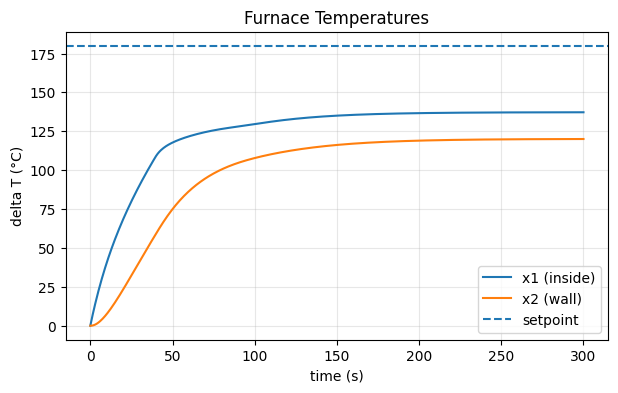

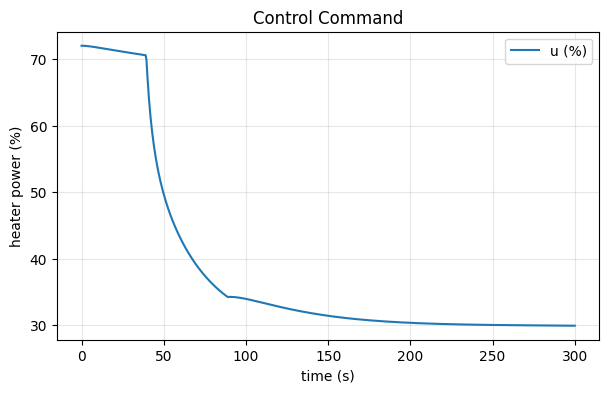

In [32]:
plt.figure()
plt.plot(ts, x1s, label="x1 (inside)")
plt.plot(ts, x2s, label="x2 (wall)")
plt.axhline(setpoint, ls='--', label="setpoint")
plt.xlabel("time (s)"); plt.ylabel("delta T (°C)")
plt.title("Furnace Temperatures")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.plot(ts, [100*u for u in us], label="u (%)")
plt.xlabel("time (s)"); plt.ylabel("heater power (%)")
plt.title("Control Command")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


# ***Inspect One Instant***

In [33]:
x1_norm = normalize(x1s[-1] - setpoint, ERR_MIN, ERR_MAX)
x2_norm = normalize(x2s[-1] - setpoint, ERR_MIN, ERR_MAX)
u_now = fuzzy_controller(x1_norm, x2_norm, x_sets, u_sets, FAM, u_universe)
print(f"Final heater command ≈ {100.0*u_now:.1f}%  |  x1={x1s[-1]:.1f}°C, x2={x2s[-1]:.1f}°C")


Final heater command ≈ 33.2%  |  x1=137.2°C, x2=120.0°C
